In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import itertools

In [ ]:
class MLP(nn.Module):
    def __init__(self, topology, activation_function, dropout_p=0.0):
        super(MLP, self).__init__()
        self.layers = nn.ModuleList()
        self.activation = activation_function()
        self.dropout = nn.Dropout(dropout_p) if dropout_p > 0 else None

        # Create layers based on topology
        for i in range(len(topology) - 1):
            self.layers.append(nn.Linear(topology[i], topology[i+1]))

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.layers) - 1:
                x = self.activation(x)
                if self.dropout is not None:
                    x = self.dropout(x)
        return x

In [ ]:
class MLPTrainer:
    def __init__(self, model, lr=None, task_type='multiclass', weight_decay=0.0, optimizer_type='sgd'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)
        self.task_type = task_type

        if lr is None:
            lr = 0.001 if optimizer_type == 'adam' else 0.01

        if optimizer_type == 'adam':
            self.optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            self.optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

        if task_type == 'binary':
            self.criterion = nn.BCEWithLogitsLoss()
        else:
            self.criterion = nn.CrossEntropyLoss()

        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def train(self, train_loader, val_loader, epochs=100, patience=5, verbose=True):
        best_loss = float('inf')
        epochs_no_improve = 0
        best_model_wts = copy.deepcopy(self.model.state_dict())
        actual_epochs = 0

        for epoch in range(epochs):
            actual_epochs += 1
            self.model.train()
            train_loss, train_correct = 0.0, 0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)

                if self.task_type == 'binary':
                    labels_for_loss = ((labels + 1) / 2).float()
                    loss = self.criterion(outputs.squeeze(), labels_for_loss)
                    preds = (torch.sigmoid(outputs.squeeze()) > 0.5).int()
                    labels_for_acc = labels_for_loss.int()
                else:
                    loss = self.criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)
                    labels_for_acc = labels.data

                loss.backward()
                self.optimizer.step()
                train_loss += loss.item() * inputs.size(0)
                train_correct += torch.sum(preds == labels_for_acc)

            train_loss /= len(train_loader.dataset)
            train_acc = train_correct.double() / len(train_loader.dataset)

            self.model.eval()
            val_loss, val_correct = 0.0, 0
            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    outputs = self.model(inputs)
                    if self.task_type == 'binary':
                        labels_for_loss = ((labels + 1) / 2).float()
                        loss = self.criterion(outputs.squeeze(), labels_for_loss)
                        preds = (torch.sigmoid(outputs.squeeze()) > 0.5).int()
                        labels_for_acc = labels_for_loss.int()
                    else:
                        loss = self.criterion(outputs, labels)
                        _, preds = torch.max(outputs, 1)
                        labels_for_acc = labels.data
                    val_loss += loss.item() * inputs.size(0)
                    val_correct += torch.sum(preds == labels_for_acc)

            val_loss /= len(val_loader.dataset)
            val_acc = val_correct.double() / len(val_loader.dataset)

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc.item())
            self.history['val_acc'].append(val_acc.item())

            if verbose:
                print(f'Epoch {epoch+1} - Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

            if val_loss < best_loss:
                best_loss = val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    self.model.load_state_dict(best_model_wts)
                    break
        return actual_epochs

    def predict(self, test_loader):
        self.model.eval()
        predictions = []
        with torch.no_grad():
            for inputs, _ in test_loader:
                inputs = inputs.to(self.device)
                outputs = self.model(inputs)
                if self.task_type == 'binary':
                    preds = (torch.sigmoid(outputs.squeeze()) > 0.5).int()
                else:
                    _, preds = torch.max(outputs, 1)
                predictions.extend(preds.cpu().numpy())
        return predictions

### DATASET 1

o DATASET 1 é linear, onde apenas um nerônio na camada escondida é para ser suficiente para resolver o problema


,topology,activation,optimizer,lr,reg_type,epochs,avg_val_acc
15,"[2, 1, 1]",ReLU,adam,0.10,dropout,100,0.950000
24,"[2, 1, 1]",Tanh,sgd,0.10,none,50,0.950000
89,"[2, 2, 1]",Tanh,adam,0.10,l2,100,0.950000
16,"[2, 1, 1]",ReLU,adam,0.10,l2,50,0.933333
76,"[2, 2, 1]",Tanh,sgd,0.10,l2,50,0.933333
...,...,...,...,...,...,...,...
11,"[2, 1, 1]",ReLU,sgd,0.01,l2,100,0.466667
33,"[2, 1, 1]",Tanh,sgd,0.01,dropout,100,0.466667
30,"[2, 1, 1]",Tanh,sgd,0.01,none,50,0.466667
55,"[2, 2, 1]",ReLU,sgd,0.01,none,100,0.466667


Gráfico salvo como: best_model_decision_boundary_-_dataset_1.png


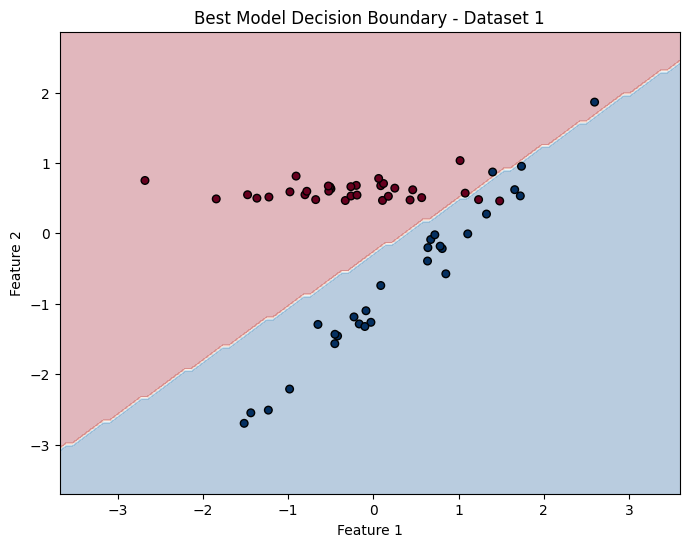

In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", task_type='binary'):
    model.eval()
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    meshgrid_inputs = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(next(model.parameters()).device)

    with torch.no_grad():
        outputs = model(meshgrid_inputs)
        if task_type == 'binary':
            Z = (torch.sigmoid(outputs.squeeze()) > 0.5).int().reshape(xx.shape).cpu().numpy()
        else:
            _, Z = torch.max(outputs, 1)
            Z = Z.reshape(xx.shape).cpu().numpy()

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu_r')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap='RdBu_r')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    filename = title.replace(" ", "_").lower() + ".png"
    plt.savefig(filename)
    print(f"Gráfico salvo como: {filename}")
    plt.show()

df_train = pd.read_csv('/content/drive/MyDrive/MLP/test_dataset1.csv')
X_raw = df_train.drop('label', axis=1).values
y_train = df_train['label'].values
scaler = StandardScaler()
X_train = scaler.fit_transform(X_raw)

input_dim, output_dim = X_train.shape[1], 1
kf = KFold(n_splits=3, shuffle=True, random_state=42)

search_space = {
    'topology': [str([input_dim, 1, output_dim]), str([input_dim, 2, output_dim])],
    'activation': [nn.ReLU, nn.Tanh],
    'optimizer': ['sgd', 'adam'],
    'lr': [0.1, 0.01],
    'reg_type': ['none', 'dropout', 'l2'],
    'epochs': [50, 100]
}

keys, values = zip(*search_space.items())
hyperparam_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

results = []
best_val_acc, best_params, best_model = -1, None, None

for params in hyperparam_combinations:
    dropout_p = 0.1 if params['reg_type'] == 'dropout' else 0.0
    wd = 0.001 if params['reg_type'] == 'l2' else 0.0
    topology_list = eval(params['topology'])

    fold_accs = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_vl = torch.FloatTensor(X_train[train_idx]), torch.FloatTensor(X_train[val_idx])
        y_tr, y_vl = torch.FloatTensor(y_train[train_idx]), torch.FloatTensor(y_train[val_idx])

        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_vl, y_vl), batch_size=32)

        model = MLP(topology_list, params['activation'], dropout_p=dropout_p)
        trainer = MLPTrainer(model, lr=params['lr'], task_type='binary', weight_decay=wd, optimizer_type=params['optimizer'])
        trainer.train(train_loader, val_loader, epochs=params['epochs'], patience=20, verbose=False)
        fold_accs.append(trainer.history['val_acc'][-1])

    avg_acc = np.mean(fold_accs)
    results.append({**params, 'activation': params['activation'].__name__, 'avg_val_acc': avg_acc})

    if avg_acc > best_val_acc:
        best_val_acc = avg_acc
        best_params = params
        best_model = copy.deepcopy(model)

df_results1 = pd.DataFrame(results).sort_values(by='avg_val_acc', ascending=False)
df_results1.to_csv('results_dataset1.csv', index=False)
display(df_results1)
plot_decision_boundary(best_model, X_train, y_train, title="Best Model Decision Boundary - Dataset 1")

Como pode ser observado, este é um problema linear, logo, não são necessários mais do que apenas 1 neurônio nas camadas escondidas.

A adição de mais um neurônio apenas aumenta os custos computacionais e não afetaram a acurácia final obtida significamente.

### DATASET 2

o DATASET 2 não é linear, logo, serão necessários N neurônios para resolver o problema, sendo N a quantidade de retas para separar as classes do dataset de maneira razoável

,topology,activation,optimizer,lr,reg_type,epochs,avg_val_acc
0,"[2, 10, 1]",ReLU,sgd,0.10,none,50,1.000000
1,"[2, 10, 1]",ReLU,sgd,0.10,none,100,1.000000
3,"[2, 10, 1]",ReLU,sgd,0.10,dropout,100,1.000000
15,"[2, 10, 1]",ReLU,adam,0.10,dropout,100,1.000000
12,"[2, 10, 1]",ReLU,adam,0.10,none,50,1.000000
...,...,...,...,...,...,...,...
58,"[2, 20, 1]",ReLU,sgd,0.01,l2,50,0.611631
35,"[2, 10, 1]",Tanh,sgd,0.01,l2,100,0.610851
80,"[2, 20, 1]",Tanh,sgd,0.01,dropout,50,0.594584
34,"[2, 10, 1]",Tanh,sgd,0.01,l2,50,0.571498


Gráfico salvo como: best_model_decision_boundary_-_dataset_2.png


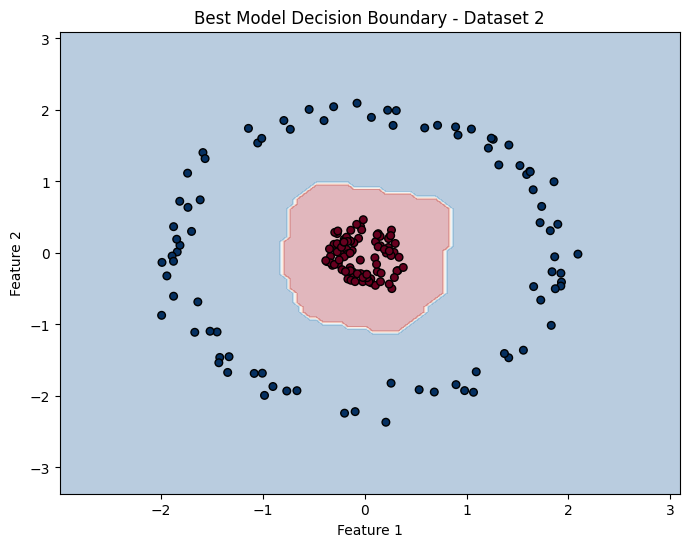

In [ ]:
df_train2 = pd.read_csv('/content/drive/MyDrive/MLP/train_dataset2.csv') # /content/drive/MyDrive/MLP/test_dataset1.csv
X_raw2 = df_train2.drop('label', axis=1).values
y_train2 = df_train2['label'].values
scaler2 = StandardScaler()
X_train2 = scaler2.fit_transform(X_raw2)

input_dim = X_train2.shape[1]
output_dim = 1
kf = KFold(n_splits=3, shuffle=True, random_state=42)

search_space = {
    'topology': [str([input_dim, 10, output_dim]), str([input_dim, 20, output_dim]), str([input_dim, 30, output_dim])],
    'activation': [nn.ReLU, nn.Tanh],
    'optimizer': ['sgd', 'adam'],
    'lr': [0.1, 0.01],
    'reg_type': ['none', 'dropout', 'l2'],
    'epochs': [50, 100]
}

keys, values = zip(*search_space.items())
hyperparam_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
results = []
best_val_acc, best_params, best_model = -1, None, None

for params in hyperparam_combinations:
    dropout_p = 0.1 if params['reg_type'] == 'dropout' else 0.0
    wd = 0.001 if params['reg_type'] == 'l2' else 0.0
    topology_list = eval(params['topology'])
    fold_accs = []
    for train_idx, val_idx in kf.split(X_train2):
        X_tr, X_vl = torch.FloatTensor(X_train2[train_idx]), torch.FloatTensor(X_train2[val_idx])
        y_tr, y_vl = torch.FloatTensor(y_train2[train_idx]), torch.FloatTensor(y_train2[val_idx])
        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_vl, y_vl), batch_size=32)
        model = MLP(topology_list, params['activation'], dropout_p=dropout_p)
        trainer = MLPTrainer(model, lr=params['lr'], task_type='binary', weight_decay=wd, optimizer_type=params['optimizer'])
        trainer.train(train_loader, val_loader, epochs=params['epochs'], patience=20, verbose=False)
        fold_accs.append(trainer.history['val_acc'][-1])
    avg_acc = np.mean(fold_accs)
    results.append({**params, 'activation': params['activation'].__name__, 'avg_val_acc': avg_acc})
    if avg_acc > best_val_acc:
        best_val_acc = avg_acc
        best_params = params
        best_model = copy.deepcopy(model)

df_results2 = pd.DataFrame(results).sort_values(by='avg_val_acc', ascending=False)
df_results2.to_csv('results_dataset2.csv', index=False)
display(df_results2)
plot_decision_boundary(best_model, X_train2, y_train2, title="Best Model Decision Boundary - Dataset 2")

### DATASET 4

In [ ]:
# 1. Carregar os datasets
df_train_loaded = pd.read_csv('/content/drive/MyDrive/MLP/train_dataset4.csv')
df_val_loaded = pd.read_csv('/content/drive/MyDrive/MLP/validation_dataset4.csv')
df_test_loaded = pd.read_csv('/content/drive/MyDrive/MLP/test_dataset4.csv')

# 2. Preparar Dados (X: [amostras, features], y: [amostras])
X_train = df_train_loaded.drop('label', axis=1).values
y_train = df_train_loaded['label'].values
X_val = df_val_loaded.drop('label', axis=1).values
y_val = df_val_loaded['label'].values
X_test = df_test_loaded.drop('label', axis=1).values
y_test = df_test_loaded['label'].values

input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

# 3. Definir Espaço de Busca
search_space = {
    'topology': [
        [input_dim, 64, num_classes],             # Pequena
        [input_dim, 128, 64, num_classes],        # Média
        [input_dim, 256, 128, 64, num_classes]    # Grande
    ],
    'activation': [nn.ReLU, nn.Tanh],
    'optimizer': ['sgd', 'adam'],
    'lr': [0.01, 0.001],
    'reg_type': ['none', 'dropout', 'l2'],
    'epochs': [50, 100]
}

keys, values = zip(*search_space.items())
hyperparam_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train)), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.FloatTensor(X_val), torch.LongTensor(y_val)), batch_size=32)

results = []
best_val_acc, best_params, best_model = -1, None, None

print(f"Iniciando busca em grade para Dataset 4 ({len(hyperparam_combinations)} combinações)...")

for params in hyperparam_combinations:
    dropout_p = 0.1 if params['reg_type'] == 'dropout' else 0.0
    wd = 0.001 if params['reg_type'] == 'l2' else 0.0

    model = MLP(params['topology'], params['activation'], dropout_p=dropout_p)
    trainer = MLPTrainer(model, lr=params['lr'], task_type='multiclass', weight_decay=wd, optimizer_type=params['optimizer'])

    trainer.train(train_loader, val_loader, epochs=params['epochs'], patience=20, verbose=False)

    val_acc = trainer.history['val_acc'][-1]
    results.append({**params, 'topology': str(params['topology']), 'activation': params['activation'].__name__, 'val_acc': val_acc})

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_params = params
        best_model = copy.deepcopy(model)

# 4. Exibir e Salvar Resultados
df_results4 = pd.DataFrame(results).sort_values(by='val_acc', ascending=False)
df_results4.to_csv('results_dataset4.csv', index=False)
print("Arquivo 'results_dataset4.csv' criado com sucesso.")
display(df_results4.head(10))

print(f"\nMelhor Acurácia Val: {best_val_acc:.4f}")
print(f"Melhor Configuração: {best_params}")

# 5. Avaliação Final no Teste
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test)), batch_size=32)
final_preds = MLPTrainer(best_model, task_type='multiclass').predict(test_loader)
final_test_acc = np.mean(final_preds == y_test)
print(f"Acurácia Final no Dataset de Teste: {final_test_acc:.4f}")

Iniciando busca em grade para Dataset 4 (144 combinações)...
Arquivo 'results_dataset4.csv' criado com sucesso.


,topology,activation,optimizer,lr,reg_type,epochs,val_acc
87,"[50, 128, 64, 4]",Tanh,adam,0.010,dropout,100,0.822917
0,"[50, 64, 4]",ReLU,sgd,0.010,none,50,0.817708
120,"[50, 256, 128, 64, 4]",Tanh,sgd,0.010,none,50,0.817708
63,"[50, 128, 64, 4]",ReLU,adam,0.010,dropout,100,0.812500
72,"[50, 128, 64, 4]",Tanh,sgd,0.010,none,50,0.812500
98,"[50, 256, 128, 64, 4]",ReLU,sgd,0.010,dropout,50,0.812500
89,"[50, 128, 64, 4]",Tanh,adam,0.010,l2,100,0.812500
92,"[50, 128, 64, 4]",Tanh,adam,0.001,dropout,50,0.812500
52,"[50, 128, 64, 4]",ReLU,sgd,0.010,l2,50,0.812500
26,"[50, 64, 4]",Tanh,sgd,0.010,dropout,50,0.812500



Melhor Acurácia Val: 0.8229
Melhor Configuração: {'topology': [50, 128, 64, 4], 'activation': <class 'torch.nn.modules.activation.Tanh'>, 'optimizer': 'adam', 'lr': 0.01, 'reg_type': 'dropout', 'epochs': 100}
Acurácia Final no Dataset de Teste: 0.8167


### Análise de Overfitting e Underfitting

Nesta seção, vamos treinar rapidamente as melhores configurações encontradas para cada uma das três arquiteturas (Pequena, Média e Grande) e visualizar suas curvas de aprendizado.

Treinando Pequena (Melhor) para gerar gráficos...
Gráfico salvo como: learning_curve_pequena_melhor.png


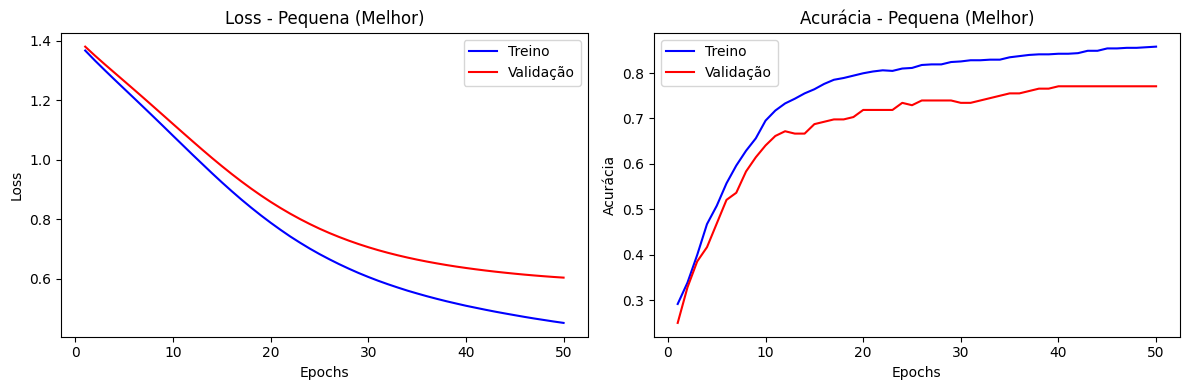

Treinando Pequena (Pior) para gerar gráficos...
Gráfico salvo como: learning_curve_pequena_pior.png


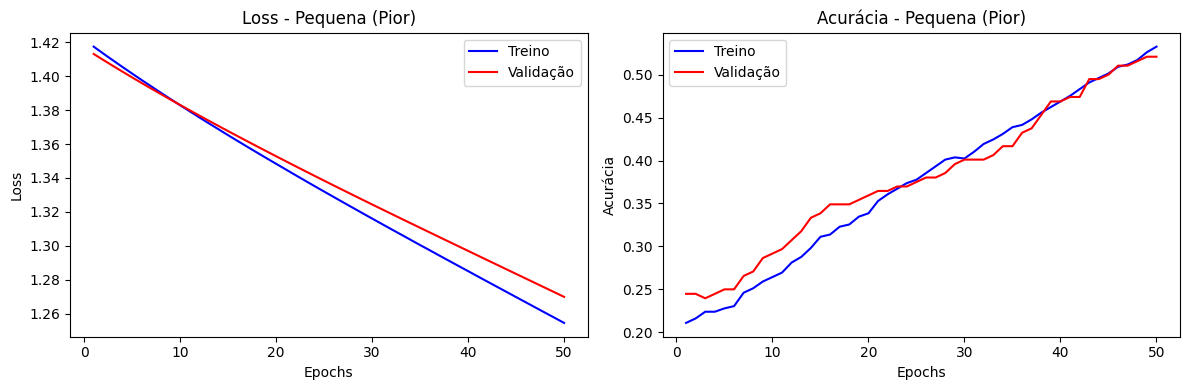

Treinando Média (Melhor) para gerar gráficos...
Gráfico salvo como: learning_curve_média_melhor.png


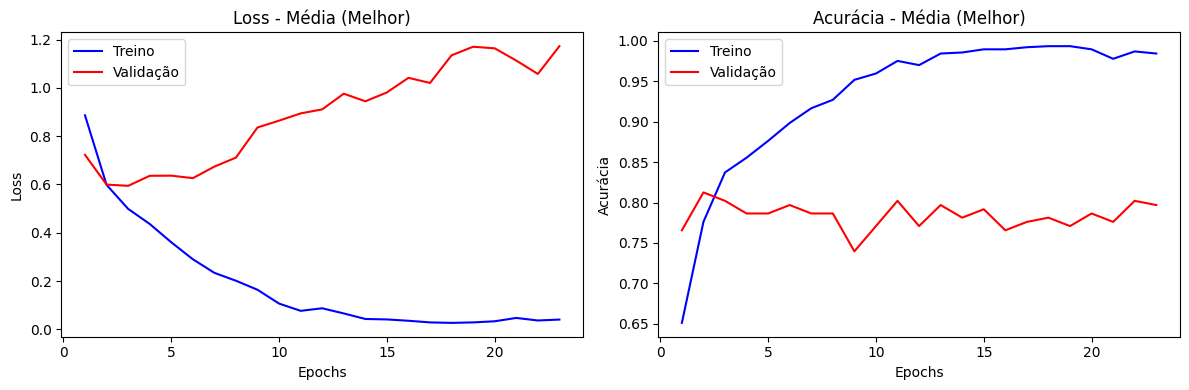

Treinando Média (Pior) para gerar gráficos...
Gráfico salvo como: learning_curve_média_pior.png


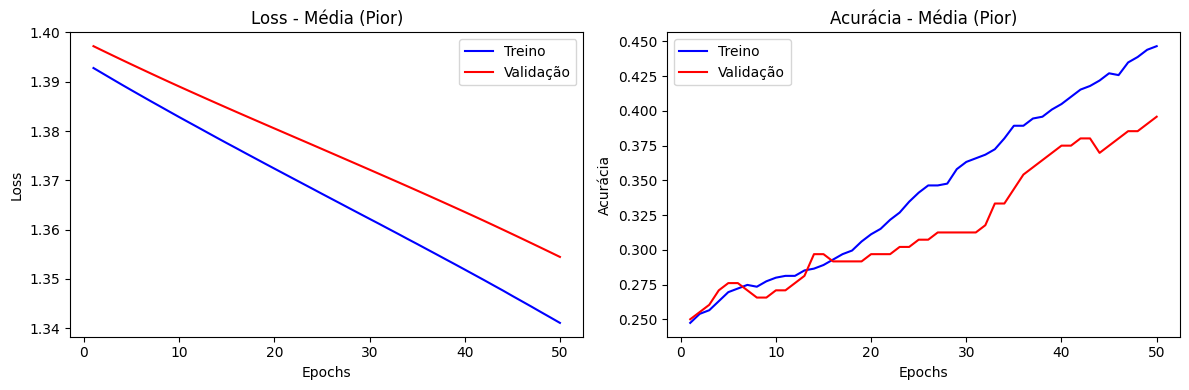

Treinando Grande (Melhor) para gerar gráficos...
Gráfico salvo como: learning_curve_grande_melhor.png


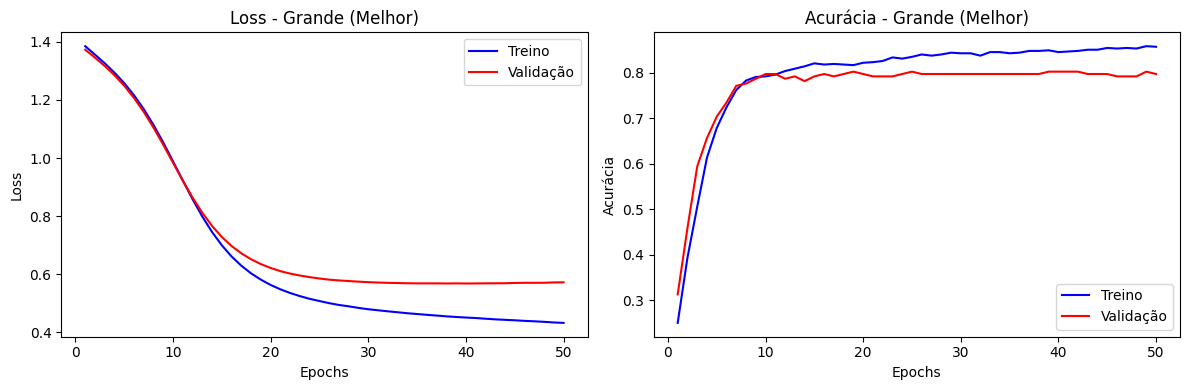

Treinando Grande (Pior) para gerar gráficos...
Gráfico salvo como: learning_curve_grande_pior.png


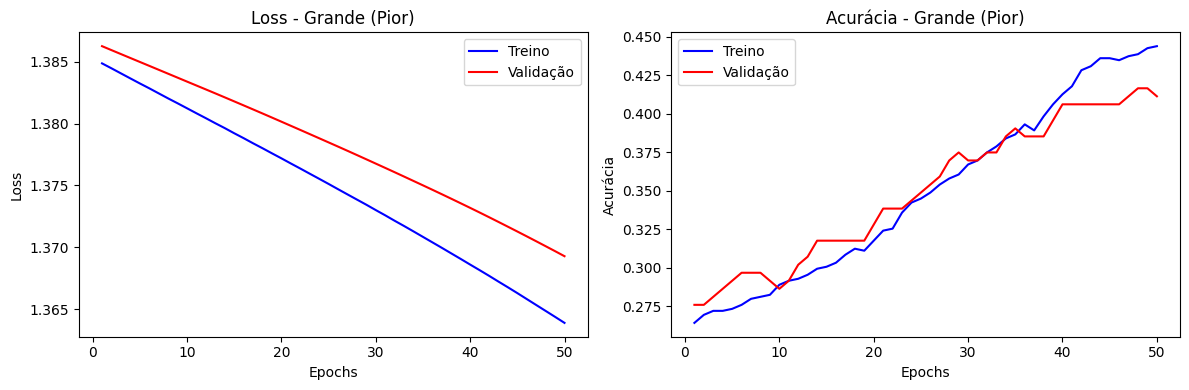

In [ ]:
def plot_learning_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Treino')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validação')
    plt.title(f'Loss - {title}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Treino')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validação')
    plt.title(f'Acurácia - {title}')
    plt.xlabel('Epochs')
    plt.ylabel('Acurácia')
    plt.legend()

    plt.tight_layout()
    filename = f"learning_curve_{title.replace(' ', '_').replace('(', '').replace(')', '').lower()}.png"
    plt.savefig(filename)
    print(f"Gráfico salvo como: {filename}")
    plt.show()

archs = {
    'Pequena': str([input_dim, 64, num_classes]),
    'Média': str([input_dim, 128, 64, num_classes]),
    'Grande': str([input_dim, 256, 128, 64, num_classes])
}

activation_map = {'ReLU': nn.ReLU, 'Tanh': nn.Tanh}

for name, top_str in archs.items():
    arch_results = df_results4[df_results4['topology'] == top_str]
    best_config = arch_results.iloc[0]
    worst_config = arch_results.iloc[-1]

    for label, config in [('Melhor', best_config), ('Pior', worst_config)]:
        act_fn = activation_map[config['activation']]
        dropout_p = 0.1 if config['reg_type'] == 'dropout' else 0.0
        wd = 0.001 if config['reg_type'] == 'l2' else 0.0

        model_test = MLP(eval(top_str), act_fn, dropout_p=dropout_p)
        trainer_test = MLPTrainer(model_test, lr=config['lr'], task_type='multiclass', weight_decay=wd, optimizer_type=config['optimizer'])

        title = f"{name} ({label})"
        print(f"Treinando {title} para gerar gráficos...")
        trainer_test.train(train_loader, val_loader, epochs=config['epochs'], patience=20, verbose=False)
        plot_learning_curves(trainer_test.history, title)

In [5]:
def analyze_top_hyperparameters(df_results, dataset_name, top_n=5):
    print(f"\n--- Análise para {dataset_name} ---")
    df_sorted = df_results.sort_values(by=df_results.columns[-1], ascending=False) # Assumes last column is accuracy/loss
    top_results = df_sorted.head(top_n)

    print(f"\nTop {top_n} resultados:")
    display(top_results[['topology', 'activation', 'optimizer', 'lr', 'reg_type', df_sorted.columns[-1]]])

    print(f"\nContagem de Otimizadores nos Top {top_n} resultados:")
    print(top_results['optimizer'].value_counts())

    print(f"\nContagem de Funções de Ativação nos Top {top_n} resultados:")
    print(top_results['activation'].value_counts())

    print(f"\nContagem de Tipos de Regularização nos Top {top_n} resultados:")
    print(top_results['reg_type'].value_counts())

# Análise para o Dataset 1
df_results1 = pd.read_csv('results_dataset1.csv')
analyze_top_hyperparameters(df_results1, 'Dataset 1', top_n=10)

# Análise para o Dataset 2
df_results2 = pd.read_csv('results_dataset2.csv')
analyze_top_hyperparameters(df_results2, 'Dataset 2', top_n=85)

# Análise para o Dataset 4
df_results4 = pd.read_csv('results_dataset4.csv')
analyze_top_hyperparameters(df_results4, 'Dataset 4', top_n=35)


--- Análise para Dataset 1 ---

Top 10 resultados:


,topology,activation,optimizer,lr,reg_type,avg_val_acc
0,"[2, 1, 1]",ReLU,adam,0.10,dropout,0.950000
1,"[2, 1, 1]",Tanh,sgd,0.10,none,0.950000
2,"[2, 2, 1]",Tanh,adam,0.10,l2,0.950000
3,"[2, 1, 1]",ReLU,adam,0.10,l2,0.933333
4,"[2, 2, 1]",Tanh,sgd,0.10,l2,0.933333
5,"[2, 2, 1]",Tanh,adam,0.01,none,0.933333
6,"[2, 2, 1]",Tanh,adam,0.10,none,0.933333
7,"[2, 1, 1]",ReLU,sgd,0.01,dropout,0.933333
8,"[2, 1, 1]",Tanh,adam,0.10,l2,0.933333
9,"[2, 2, 1]",ReLU,sgd,0.10,none,0.933333



Contagem de Otimizadores nos Top 10 resultados:
optimizer
adam    6
sgd     4
Name: count, dtype: int64

Contagem de Funções de Ativação nos Top 10 resultados:
activation
Tanh    6
ReLU    4
Name: count, dtype: int64

Contagem de Tipos de Regularização nos Top 10 resultados:
reg_type
none       4
l2         4
dropout    2
Name: count, dtype: int64

--- Análise para Dataset 2 ---

Top 85 resultados:


,topology,activation,optimizer,lr,reg_type,avg_val_acc
0,"[2, 10, 1]",ReLU,sgd,0.10,none,1.0
1,"[2, 10, 1]",ReLU,sgd,0.10,none,1.0
2,"[2, 10, 1]",ReLU,sgd,0.10,dropout,1.0
3,"[2, 10, 1]",ReLU,adam,0.10,dropout,1.0
4,"[2, 10, 1]",ReLU,adam,0.10,none,1.0
...,...,...,...,...,...,...
80,"[2, 30, 1]",ReLU,adam,0.10,l2,1.0
81,"[2, 30, 1]",Tanh,adam,0.10,none,1.0
82,"[2, 30, 1]",Tanh,adam,0.01,none,1.0
83,"[2, 30, 1]",Tanh,adam,0.01,none,1.0



Contagem de Otimizadores nos Top 85 resultados:
optimizer
adam    68
sgd     17
Name: count, dtype: int64

Contagem de Funções de Ativação nos Top 85 resultados:
activation
ReLU    50
Tanh    35
Name: count, dtype: int64

Contagem de Tipos de Regularização nos Top 85 resultados:
reg_type
none       29
dropout    28
l2         28
Name: count, dtype: int64

--- Análise para Dataset 4 ---

Top 35 resultados:


,topology,activation,optimizer,lr,reg_type,val_acc
0,"[50, 128, 64, 4]",Tanh,adam,0.010,dropout,0.822917
1,"[50, 64, 4]",ReLU,sgd,0.010,none,0.817708
2,"[50, 256, 128, 64, 4]",Tanh,sgd,0.010,none,0.817708
3,"[50, 128, 64, 4]",ReLU,adam,0.010,dropout,0.812500
4,"[50, 128, 64, 4]",Tanh,sgd,0.010,none,0.812500
5,"[50, 256, 128, 64, 4]",ReLU,sgd,0.010,dropout,0.812500
6,"[50, 128, 64, 4]",Tanh,adam,0.010,l2,0.812500
7,"[50, 128, 64, 4]",Tanh,adam,0.001,dropout,0.812500
8,"[50, 128, 64, 4]",ReLU,sgd,0.010,l2,0.812500
9,"[50, 64, 4]",Tanh,sgd,0.010,dropout,0.812500



Contagem de Otimizadores nos Top 35 resultados:
optimizer
sgd     21
adam    14
Name: count, dtype: int64

Contagem de Funções de Ativação nos Top 35 resultados:
activation
Tanh    23
ReLU    12
Name: count, dtype: int64

Contagem de Tipos de Regularização nos Top 35 resultados:
reg_type
dropout    12
l2         12
none       11
Name: count, dtype: int64


In [ ]:
import glob
import zipfile
from google.colab import files

# Nome do arquivo de saída
zip_filename = 'resultados_mlp.zip'

# Buscar todos os arquivos .csv e .png no diretório atual
files_to_zip = glob.glob('*.csv') + glob.glob('*.png')

if files_to_zip:
    with zipfile.ZipFile(zip_filename, 'w') as zipf:
        for file in files_to_zip:
            zipf.write(file)
            print(f'Adicionado ao ZIP: {file}')

    print(f'\nDownload iniciando: {zip_filename}')
    files.download(zip_filename)
else:
    print('Nenhum arquivo CSV ou PNG encontrado para baixar.')

Adicionado ao ZIP: results_dataset2.csv
Adicionado ao ZIP: results_dataset1.csv
Adicionado ao ZIP: results_dataset4.csv
Adicionado ao ZIP: learning_curve_pequena_pior.png
Adicionado ao ZIP: learning_curve_média_melhor.png
Adicionado ao ZIP: learning_curve_média_pior.png
Adicionado ao ZIP: learning_curve_grande_pior.png
Adicionado ao ZIP: best_model_decision_boundary_-_dataset_1.png
Adicionado ao ZIP: learning_curve_pequena_melhor.png
Adicionado ao ZIP: best_model_decision_boundary_-_dataset_2.png
Adicionado ao ZIP: learning_curve_grande_melhor.png

Download iniciando: resultados_mlp.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>